# 01 · The dense ("linear") model

**ERA V5 · Session 14 (Mixture-of-Experts)**, part 1 of 3.

We start from a small Transformer LM whose feed-forward block is a **single dense SwiGLU network** — the model we will later convert into a Mixture-of-Experts. Byte-level (vocab 256), so the parameters live in the transformer, not a big embedding.

| setting | value |
|---|---|
| params | ~14.5M |
| layers × width | 6 × 384 |
| heads | 6 |
| context | 512 |
| FFN | SwiGLU, hidden 1536 |
| data | TinyStories (raw UTF-8 bytes) |
| device | Apple M3 Max (MPS) |

In [1]:
import os, sys, json
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "moe")):
        REPO = p
        if p not in sys.path: sys.path.insert(0, p)
        break
assert REPO, "could not locate the moe package"
RESULTS = os.path.join(REPO, "results")
import torch
from moe.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/MixtureOfExperts | device: mps | torch: 2.13.0


## The SwiGLU feed-forward
`E(x) = W_down( SiLU(W_gate x) ⊙ W_up x )`. In the dense model there is exactly one of these per layer; the MoE model will hold several as experts.

In [2]:
from moe.model import GPT, GPTConfig
cfg = GPTConfig(ffn='dense')
model = GPT(cfg)
print(f'total params : {model.num_params()/1e6:.2f}M')
print(f'active params: {model.active_params()/1e6:.2f}M  (dense uses all of them)')

total params : 14.46M
active params: 14.46M  (dense uses all of them)


## Data — byte level
Raw UTF-8 bytes of TinyStories; `prepare()` caches `data/{train,val}.bin`.

In [3]:
from moe.data import prepare, ByteData
train_bin, val_bin = prepare()
td = ByteData(train_bin)
print('train bytes:', f'{len(td):,}')
print(bytes(td.data[:80].tolist()).decode('utf-8', 'replace'))

[data] cached: /Users/sokorada/Documents/ERA_V5/MixtureOfExperts/data/train.bin, /Users/sokorada/Documents/ERA_V5/MixtureOfExperts/data/val.bin
train bytes: 40,000,000
One day, a little girl named Lily found a needle in her room. She knew it was di


## Short live demo
A few hundred steps to show the loop runs and the loss falls. The reported numbers come from the full run below.

In [4]:
from moe.engine import train_run
demo,_ = train_run(cfg, 'demo_dense', batch_size=16, token_budget=16*512*120,
                   train_bin=train_bin, val_bin=val_bin, device=DEVICE, log_every=30)
print(demo.summary())

[demo_dense] step     0/120 loss 5.8194 24,814 tok/s


[demo_dense] step    30/120 loss 2.6517 22,175 tok/s


[demo_dense] step    60/120 loss 2.3824 22,645 tok/s


[demo_dense] step    90/120 loss 2.3544 22,971 tok/s


[demo_dense] step   119/120 loss 2.3341 23,904 tok/s


demo_dense: ffn=dense params=14.46M (active 14.46M) val_loss=2.3301 speed=23,904 tok/s


## Full run (loaded from results/dense.json)

In [5]:
r = json.load(open(os.path.join(RESULTS,'dense.json')))
print(f"final train loss: {r['final_train_loss']:.4f}")
print(f"final val loss  : {r['final_val_loss']:.4f}")
print(f"speed           : {r['tokens_per_sec']:,.0f} tok/s")
print(f"tokens seen     : {r['tokens_seen']:,} over {r['steps']:,} steps")

final train loss: 0.9276
final val loss  : 0.9312
speed           : 24,029 tok/s
tokens seen     : 19,988,480 over 1,220 steps


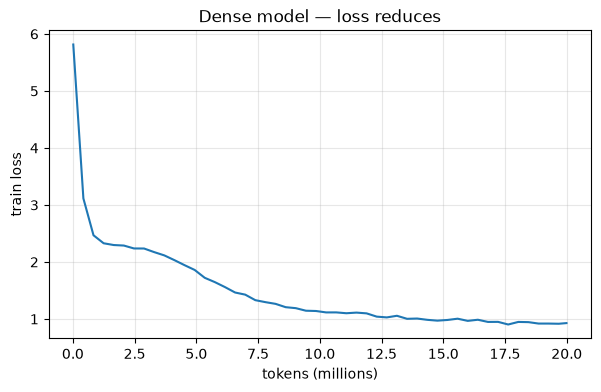

In [6]:
import matplotlib.pyplot as plt
h=r['history']; plt.figure(figsize=(7,4))
plt.plot([x['tokens']/1e6 for x in h],[x['train_loss'] for x in h])
plt.xlabel('tokens (millions)'); plt.ylabel('train loss')
plt.title('Dense model — loss reduces'); plt.grid(alpha=0.3); plt.show()

➡️ Next: **02 · The MoE layer** — convert this dense FFN into a router + experts.